<a href="https://colab.research.google.com/github/anathayna/tcc/blob/main/tcc_final_shot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="orange">**TCC: Identificação do discurso de ódio em memes**</font>

O Google Colab é uma plataforma baseada em Jupyter Notebook que oferece um ambiente de execução em nuvem com recursos gratuitos de GPU e TPU, amplamente utilizado em projetos de aprendizado de máquina e processamento de linguagem natural.

Este notebook implementa um **pipeline completo** para detecção de discurso de ódio em memes multimodais, combinando:
- **HateCLIPper** — classificador multimodal baseado em CLIP (Kumar & Nandakumar, EMNLP 2022)
- **RGCL** — módulo de raciocínio causal com Graph Convolutional Network Relacional
- **IntMeme Fallback** — árbitro zero-shot CLIP para casos incertos
- **Lógica Fuzzy** — graduação contínua do nível de ódio

# <font color="orange">**Sumário**</font>

1.   Bibliotecas e dependências
2.   Banco de dados
3.   Arquitetura
4.   Treinamento
5.   Avaliação
6.   Demo

## <font color="orange">1. Bibliotecas e dependências</font>

In [1]:
!pip install -q jsonlines
!pip install -q transformers
!pip install -q torchmetrics
!pip install -q scikit-fuzzy
!pip install -q ftfy regex tqdm
!pip install -q torch-geometric
!pip install -q pytorch-lightning
!pip install -q torch torchvision torchaudio
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q scikit-learn numpy datasets matplotlib seaborn pandas Pillow ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 909.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 22.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import clip
import json
import copy
import time
import torch
import random
import shutil
import zipfile
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import torch.nn.functional as F
import matplotlib.patches as mpatches

from PIL import Image
from google.colab import drive
from torchvision import transforms
from transformers import CLIPModel
from skfuzzy import control as ctrl
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.metrics import (roc_curve, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from transformers import (CLIPProcessor, CLIPTokenizer, AutoTokenizer,
                           AutoModelForSequenceClassification, pipeline)

warnings.filterwarnings("ignore")

In [3]:
DATA_ROOT = "/content/drive/MyDrive/hateful_memes"

class Config:
    data_root        = DATA_ROOT
    image_size       = 224

    clip_model       = "openai/clip-vit-large-patch14"
    fusion           = "cross"

    map_dim          = 256
    num_map_layers   = 1
    num_pre_output   = 1
    drop_probs       = (0.1, 0.4, 0.2)  # controle de overfitting

    w_image_loss     = 1.0
    w_text_loss      = 1.0

    batch_size       = 16
    lr               = 1e-4
    weight_decay     = 1e-4
    max_epochs       = 20
    grad_clip        = 0.1
    seed             = 42

    output_dir       = f"{DATA_ROOT}/outputs"
    device           = "cuda" if torch.cuda.is_available() else "cpu"

Config = Config()
os.makedirs(Config.output_dir, exist_ok=True)

HOME = os.getcwd()

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(Config.seed)
print("⚙️ Configuração carregada:\n")
for key in dir(Config):
    if not key.startswith('__'):
        val = getattr(Config, key)
        print(f"   {key:<16}: {str(val):<30}")

⚙️ Configuração carregada:

   batch_size      : 16                            
   clip_model      : openai/clip-vit-large-patch14 
   data_root       : /content/drive/MyDrive/hateful_memes
   device          : cuda                          
   drop_probs      : (0.1, 0.4, 0.2)               
   fusion          : cross                         
   grad_clip       : 0.1                           
   image_size      : 224                           
   lr              : 0.0001                        
   map_dim         : 256                           
   max_epochs      : 20                            
   num_map_layers  : 1                             
   num_pre_output  : 1                             
   output_dir      : /content/drive/MyDrive/hateful_memes/outputs
   seed            : 42                            
   w_image_loss    : 1.0                           
   w_text_loss     : 1.0                           
   weight_decay    : 0.0001                        


## <font color="orange">2. Banco de dados</font>

O banco de dados utilizado é o **Hateful Memes** disponibilizado pela Meta no *Challenge Hateful Memes* — mais de **10 mil** imagens de memes em inglês com conteúdo potencialmente ofensivo relacionado a gênero, raça, religião, orientação sexual e outros tópicos.

O conjunto é composto por:
- **40%** memes de ódio multimodal: texto e imagem, em conjunto, transmitem ódio
- **20%** confounders de texto: texto de ódio com imagem benigna
- **20%** confounders de imagem: imagem de ódio com texto benigno
- **20%** memes benignos (não-ódio)

Os rótulos são **0 = non-hateful** e **1 = hateful**.

In [4]:
#@markdown Defina o caminho para o arquivo **.zip** do banco de dados do *Hateful Memes*.
#@markdown **exemplo:** `"/content/drive/MyDrive/hateful_memes.zip"`

PATH_TO_ZIP_FILE = '/content/drive/MyDrive/hateful_memes.zip'  #@param {type:"string"}

In [6]:
#!rm -rf /content/drive

In [7]:
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
os.chdir(HOME)
os.getcwd()
os.environ['PYTHONPATH'] += ":/content/model/"

In [9]:
zip_path = PATH_TO_ZIP_FILE
extract_path = '/content/model/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extraído com sucesso!")

✅ Dataset extraído com sucesso!


In [10]:
img_dir = '/content/model/hateful_memes/img'

image_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp']

image_count = 0
for filename in os.listdir(img_dir):
    if any(filename.lower().endswith(ext) for ext in image_extensions):
        image_count += 1

print(f"📁 Total de imagens encontradas: {image_count}")

📁 Total de imagens encontradas: 12140


- Pasta `img/` — contém as imagens (formato .png) correspondentes aos memes.
- Arquivos `.jsonl`:
  - **train.jsonl** — conjunto de treinamento, com rótulos disponíveis (0 = non-hateful, 1 = hateful)
  - **dev_seen.jsonl** — conjunto de validação (seen)
  - **dev_unseen.jsonl** — conjunto de validação (unseen)
  - **test_seen.jsonl** — conjunto de teste (seen)
  - **test_unseen.jsonl** — conjunto de teste (unseen)

In [11]:
import jsonlines

base_path = '/content/model/hateful_memes/'

def read_jsonl_to_dataframe(jsonl_path):
    data = []
    with jsonlines.open(jsonl_path) as reader:
        for obj in reader:
            data.append(obj)
    return pd.DataFrame(data)

df_train      = read_jsonl_to_dataframe(base_path + 'train.jsonl')
df_dev_seen   = read_jsonl_to_dataframe(base_path + 'dev_seen.jsonl')
df_test_seen  = read_jsonl_to_dataframe(base_path + 'test_seen.jsonl')
df_dev_unseen = read_jsonl_to_dataframe(base_path + 'dev_unseen.jsonl')
df_test_unseen= read_jsonl_to_dataframe(base_path + 'test_unseen.jsonl')

print(f"Train      : {len(df_train):>5} amostras")
print(f"Dev seen   : {len(df_dev_seen):>5} amostras")
print(f"Test seen  : {len(df_test_seen):>5} amostras")
print(f"Dev unseen : {len(df_dev_unseen):>5} amostras")
print(f"Test unseen: {len(df_test_unseen):>5} amostras")

Train      :  8500 amostras
Dev seen   :   500 amostras
Test seen  :  1000 amostras
Dev unseen :   540 amostras
Test unseen:  2000 amostras


In [14]:
label_map = {0: 'non-hateful', 1: 'hateful'}

dfs = {
    'df_train': df_train,
    'df_dev_seen': df_dev_seen,
    'df_test_seen': df_test_seen,
    'df_dev_unseen': df_dev_unseen,
    'df_test_unseen': df_test_unseen
}

for name, df in dfs.items():
    if 'label' in df.columns:
        print(f"\n{name}:")
        counts = df['label'].map(label_map).value_counts()
        percentages = df['label'].map(label_map).value_counts(normalize=True) * 100
        summary = pd.DataFrame({'Quantidade': counts, 'Porcentagem (%)': percentages.round(2)})
        display(summary)



df_train:


,Quantidade,Porcentagem (%)
label,,
non-hateful,5481,64.48
hateful,3019,35.52



df_dev_seen:


,Quantidade,Porcentagem (%)
label,,
non-hateful,253,50.6
hateful,247,49.4



df_test_seen:


,Quantidade,Porcentagem (%)
label,,
non-hateful,510,51.0
hateful,490,49.0



df_dev_unseen:


,Quantidade,Porcentagem (%)
label,,
non-hateful,340,62.96
hateful,200,37.04



df_test_unseen:


,Quantidade,Porcentagem (%)
label,,
non-hateful,1250,62.5
hateful,750,37.5


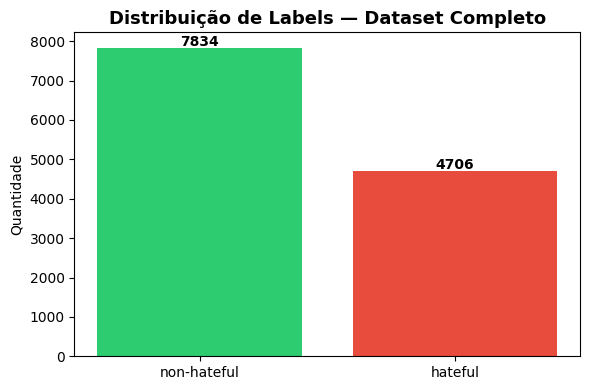

In [15]:
labeled_dfs = [df_train, df_dev_seen, df_test_seen, df_dev_unseen, df_test_unseen]
df_total = pd.concat(labeled_dfs, ignore_index=True)

value_counts_total = df_total['label'].value_counts().reset_index()
value_counts_total.columns = ['label', 'count']
value_counts_total['label'] = value_counts_total['label'].map(label_map)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(value_counts_total['label'], value_counts_total['count'],
       color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribuição de Labels — Dataset Completo', fontsize=13, fontweight='bold')
ax.set_ylabel('Quantidade')
for bar, count in zip(ax.patches, value_counts_total['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
class HatefulMemesDataset(Dataset):
    def __init__(self, root, split="train", image_size=224):
        self.root       = root
        self.split      = split
        self.image_size = image_size

        jsonl_path = os.path.join(root, f"{split}.jsonl")
        with open(jsonl_path, "r") as f:
            self.samples = [json.loads(l) for l in f]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(os.path.join(self.root, s["img"])).convert("RGB")
        img = img.resize((self.image_size, self.image_size))
        return {
            "image": img,
            "text" : s["text"],
            "label": int(s.get("label", 0)),
            "id"   : int(s["id"]),
        }


class HatefulMemesPrep:
    def __init__(self, clip_model_name):
        self.processor = CLIPProcessor.from_pretrained(clip_model_name)
        self.tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)

    def __call__(self, batch):
        images  = [b["image"]  for b in batch]
        texts   = [b["text"]   for b in batch]
        labels  = torch.LongTensor([b["label"] for b in batch])
        ids     = [b["id"]     for b in batch]

        pv = self.processor(images=images, return_tensors="pt")["pixel_values"]
        tk = self.tokenizer(texts, padding=True, truncation=True,
                            max_length=77, return_tensors="pt")
        return {
            "pixel_values"  : pv,
            "input_ids"     : tk["input_ids"],
            "attention_mask": tk["attention_mask"],
            "labels"        : labels,
            "ids"           : ids,
        }


prep = HatefulMemesPrep(Config.clip_model)

data_root = base_path

ds_train      = HatefulMemesDataset(data_root, "train",      Config.image_size)
ds_dev_seen   = HatefulMemesDataset(data_root, "dev_seen",   Config.image_size)
ds_test_seen  = HatefulMemesDataset(data_root, "test_seen",  Config.image_size)
ds_dev_unseen = HatefulMemesDataset(data_root, "dev_unseen", Config.image_size)

dl_train    = DataLoader(ds_train,    batch_size=Config.batch_size, shuffle=True,
                         num_workers=2, collate_fn=prep, pin_memory=True)
dl_dev_seen = DataLoader(ds_dev_seen, batch_size=Config.batch_size, shuffle=False,
                         num_workers=2, collate_fn=prep, pin_memory=True)
dl_test_seen= DataLoader(ds_test_seen,batch_size=Config.batch_size, shuffle=False,
                         num_workers=2, collate_fn=prep, pin_memory=True)

print(f"✅ Datasets carregados:")
print(f"  Train      : {len(ds_train)} amostras  ({len(dl_train)} batches)")
print(f"  Dev seen   : {len(ds_dev_seen)} amostras  ({len(dl_dev_seen)} batches)")
print(f"  Test seen  : {len(ds_test_seen)} amostras  ({len(dl_test_seen)} batches)")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ Datasets carregados:
  Train      : 8500 amostras  (532 batches)
  Dev seen   : 500 amostras  (32 batches)
  Test seen  : 1000 amostras  (63 batches)


## <font color="orange">3. Arquitetura</font>

O pipeline é composto por quatro módulos:

1. **HateCLIPper** — extrai embeddings visuais e textuais via CLIP e os funde para classificação binária
2. **RGCL (Relational Graph Convolutional Learning)** — constrói um grafo de relações entre os nós visual/textual e propaga informação contextual via GCN
3. **IntMeme Fallback** — para scores no intervalo de incerteza [0.35, 0.65], um proxy zero-shot CLIP é acionado como árbitro
4. **FuzzyHateGrader** — converte o score final em uma graduação contínua de ódio usando lógica fuzzy

### 3.1 HateCLIPper + extração de features CLIP

In [35]:
clip_model = CLIPModel.from_pretrained(Config.clip_model).to(Config.device)
clip_model.eval()

for param in clip_model.parameters():
    param.requires_grad = False

print(f"✅ CLIP carregado e congelado ({Config.clip_model})")
print(f"   Dispositivo: {Config.device}")


class HateCLIPper(nn.Module):
    """
    Hate-CLIPper: Kumar & Nandakumar (EMNLP 2022) — adaptado com fusion modes.
    Modes: 'concat' | 'cross' | 'both' (concat + element-wise)
    """
    def __init__(self, embed_dim=768, hidden_dim=256, fusion_mode='cross', dropout=0.3):
        super().__init__()
        self.fusion_mode = fusion_mode

        if fusion_mode == 'concat':
            fused_dim = embed_dim * 2
        elif fusion_mode == 'cross':
            fused_dim = embed_dim
        else:  # 'both'
            fused_dim = embed_dim * 3

        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def fuse(self, visual_emb, text_emb):
        v = F.normalize(visual_emb, dim=-1)
        t = F.normalize(text_emb,   dim=-1)
        if   self.fusion_mode == 'concat': return torch.cat([v, t], dim=-1)
        elif self.fusion_mode == 'cross':  return v * t
        else:                               return torch.cat([v, t, v * t], dim=-1)

    def forward(self, visual_emb, text_emb):
        fused = self.fuse(visual_emb, text_emb)
        logit = self.classifier(fused)
        return torch.sigmoid(logit).squeeze(-1)


@torch.no_grad()
def extract_clip_features(pixel_values, input_ids, attention_mask):
    """Extrai embeddings CLIP (visual + textual) sem gradiente."""
    pixel_values  = pixel_values.to(Config.device)
    input_ids     = input_ids.to(Config.device)
    attention_mask= attention_mask.to(Config.device)

    visual_emb = clip_model.get_image_features(pixel_values=pixel_values)
    text_emb   = clip_model.get_text_features(
        input_ids=input_ids, attention_mask=attention_mask
    )


    if not isinstance(visual_emb, torch.Tensor):
        visual_emb = getattr(visual_emb, 'pooler_output', visual_emb[0] if isinstance(visual_emb, tuple) else visual_emb)
    if not isinstance(text_emb, torch.Tensor):
        text_emb = getattr(text_emb, 'pooler_output', text_emb[0] if isinstance(text_emb, tuple) else text_emb)

    return visual_emb.float(), text_emb.float()


hateclipper = HateCLIPper(
    embed_dim=768, hidden_dim=256,
    fusion_mode='cross', dropout=0.3
).to(Config.device)

print(f"✅ HateCLIPper instanciado — fusion_mode='cross'")
trainable = sum(p.numel() for p in hateclipper.parameters() if p.requires_grad)
print(f"   Parâmetros treináveis: {trainable:,}")


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP carregado e congelado (openai/clip-vit-large-patch14)
   Dispositivo: cuda
✅ HateCLIPper instanciado — fusion_mode='cross'
   Parâmetros treináveis: 213,889


### 3.2 RGCL — Relational Graph Convolutional Learning

In [36]:
class RelationalGCNLayer(nn.Module):
    """
    Camada de Graph Convolution com atenção relacional.
    Agrega features de vizinhos ponderadas por relevância semântica.
    """
    def __init__(self, in_dim, out_dim, num_relations=3):
        super().__init__()
        self.relation_weights = nn.ModuleList([
            nn.Linear(in_dim, out_dim, bias=False)
            for _ in range(num_relations)
        ])
        self.self_loop = nn.Linear(in_dim, out_dim)
        self.norm      = nn.LayerNorm(out_dim)
        self.activation= nn.GELU()

    def forward(self, node_features, adjacency_matrices):
        out = self.self_loop(node_features)
        for W, A in zip(self.relation_weights, adjacency_matrices):
            D_inv  = (A.sum(dim=-1, keepdim=True) + 1e-8).pow(-0.5)
            A_norm = D_inv * A * D_inv.T
            out    = out + A_norm @ W(node_features)
        return self.activation(self.norm(out))


class RGCL(nn.Module):
    """
    Módulo RGCL para raciocínio causal em memes multimodais.
    Constrói grafo visual-textual e propaga via GCN relacional.
    """
    def __init__(self, embed_dim=768, hidden_dim=256, n_gcn_layers=2, dropout=0.3):
        super().__init__()
        self.embed_dim = embed_dim

        self.proj_visual = nn.Linear(embed_dim, hidden_dim)
        self.proj_text   = nn.Linear(embed_dim, hidden_dim)

        self.gcn_layers = nn.ModuleList([
            RelationalGCNLayer(hidden_dim, hidden_dim, num_relations=3)
            for _ in range(n_gcn_layers)
        ])

        self.attention  = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def build_adjacency(self, visual_emb, text_emb):
        B = visual_emb.shape[0]
        v_norm    = F.normalize(visual_emb, dim=-1)
        t_norm    = F.normalize(text_emb,   dim=-1)
        cross_sim = (v_norm * t_norm).sum(dim=-1, keepdim=True)

        A_vv   = torch.eye(2, device=Config.device).unsqueeze(0).expand(B, -1, -1)
        A_tt   = torch.eye(2, device=Config.device).unsqueeze(0).expand(B, -1, -1)
        A_cross= torch.zeros(B, 2, 2, device=Config.device)
        A_cross[:, 0, 1] = cross_sim.squeeze(-1).clamp(0, 1)
        A_cross[:, 1, 0] = cross_sim.squeeze(-1).clamp(0, 1)

        return [A_vv, A_tt, A_cross]

    def forward(self, visual_emb, text_emb):
        B = visual_emb.shape[0]
        v_proj = self.proj_visual(visual_emb)
        t_proj = self.proj_text(text_emb)
        nodes  = torch.stack([v_proj, t_proj], dim=1)

        adjacencies = self.build_adjacency(visual_emb, text_emb)

        for gcn_layer in self.gcn_layers:
            updated = [gcn_layer(nodes[b], [A[b] for A in adjacencies])
                       for b in range(B)]
            nodes   = torch.stack(updated, dim=0)

        attn_weights = torch.softmax(self.attention(nodes), dim=1)
        aggregated   = (attn_weights * nodes).sum(dim=1)

        combined = torch.cat([nodes[:, 0], nodes[:, 1]], dim=-1)
        logit    = self.classifier(combined)
        return torch.sigmoid(logit).squeeze(-1)


rgcl = RGCL(embed_dim=768, hidden_dim=256, n_gcn_layers=2, dropout=0.3).to(Config.device)
print(f"✅ RGCL instanciado com {sum(p.numel() for p in rgcl.parameters() if p.requires_grad):,} parâmetros")


✅ RGCL instanciado com 1,001,858 parâmetros


### 3.3 IntMeme Fallback — Árbitro de Incerteza

In [43]:
class IntMemeFallback:
    """
    IntMeme como árbitro para casos incertos (score ∈ [0.35, 0.65]).
    Por padrão usa zero-shot CLIP como proxy eficiente.
    Para usar o modelo real: IntMemeFallback(use_real_model=True, model_id="<caminho>")
    """

    HATE_PROMPTS = [
        "a hateful meme targeting a group of people",
        "a meme with offensive content promoting discrimination",
        "a meme with hate speech against a minority",
        "an extremely offensive and hateful meme",
        "a meme promoting racism or xenophobia"
    ]
    BENIGN_PROMPTS = [
        "a harmless and funny meme",
        "a benign meme without offensive content",
        "a positive and inclusive meme",
        "a normal internet meme",
        "a meme celebrating diversity and inclusion"
    ]

    def __init__(self, use_real_model=False, model_id=None):
        self.use_real_model = use_real_model
        self.model          = None
        self.call_count     = 0

        if use_real_model and model_id:
            self._load_real_model(model_id)
        else:
            print("IntMeme: modo zero-shot CLIP (proxy eficiente)")
            print("Para modelo real: IntMemeFallback(use_real_model=True, model_id='<path>')")

    def _load_real_model(self, model_id):
        try:
            from transformers import BitsAndBytesConfig
            bnb_config = BitsAndBytesConfig(load_in_4bit=True,
                                             bnb_4bit_compute_dtype=torch.float16)
            self.model = AutoModelForSequenceClassification.from_pretrained(
                model_id, quantization_config=bnb_config, device_map='auto'
            )
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            print(f"✅ IntMeme real carregado de {model_id}")
        except Exception as e:
            print(f"Erro ao carregar modelo real: {e}. Usando zero-shot CLIP.")
            self.use_real_model = False

    @torch.no_grad()
    def _zero_shot_clip(self, visual_emb, text_emb, **kwargs):
        hate_inputs   = prep.tokenizer(self.HATE_PROMPTS,   padding=True,
                                        truncation=True, return_tensors="pt").to(Config.device)
        benign_inputs = prep.tokenizer(self.BENIGN_PROMPTS, padding=True,
                                        truncation=True, return_tensors="pt").to(Config.device)

        hate_embs_out   = clip_model.get_text_features(**hate_inputs)
        benign_embs_out = clip_model.get_text_features(**benign_inputs)

        if not isinstance(hate_embs_out, torch.Tensor):
            hate_embs = getattr(hate_embs_out, 'pooler_output', hate_embs_out[0] if isinstance(hate_embs_out, tuple) else hate_embs_out).float()
        else:
            hate_embs = hate_embs_out.float()

        if not isinstance(benign_embs_out, torch.Tensor):
            benign_embs = getattr(benign_embs_out, 'pooler_output', benign_embs_out[0] if isinstance(benign_embs_out, tuple) else benign_embs_out).float()
        else:
            benign_embs = benign_embs_out.float()

        v_norm      = F.normalize(visual_emb, dim=-1)
        sim_hate    = (v_norm @ F.normalize(hate_embs,   dim=-1).mT).mean(dim=-1)
        sim_benign  = (v_norm @ F.normalize(benign_embs, dim=-1).mT).mean(dim=-1)

        logits = torch.stack([sim_benign, sim_hate], dim=-1) * 100
        return torch.softmax(logits, dim=-1)[:, 1]

    def __call__(self, visual_emb, text_emb, **kwargs):
        self.call_count += 1
        if self.use_real_model and self.model is not None:
            return self._real_model_inference(**kwargs)
        return self._zero_shot_clip(visual_emb, text_emb)

    def _real_model_inference(self, text_raw, **kwargs):
        inputs = self.tokenizer(text_raw, return_tensors='pt',
                                truncation=True, padding=True).to(Config.device)
        with torch.no_grad():
            logits = self.model(**inputs).logits
        return torch.softmax(logits, dim=-1)[:, 1]

    def get_stats(self):
        return {'total_calls': self.call_count}


intmeme = IntMemeFallback(use_real_model=False)
print("✅ IntMeme pronto")


IntMeme: modo zero-shot CLIP (proxy eficiente)
Para modelo real: IntMemeFallback(use_real_model=True, model_id='<path>')
✅ IntMeme pronto


### 3.4 FuzzyHateGrader — Graduação Contínua de Ódio

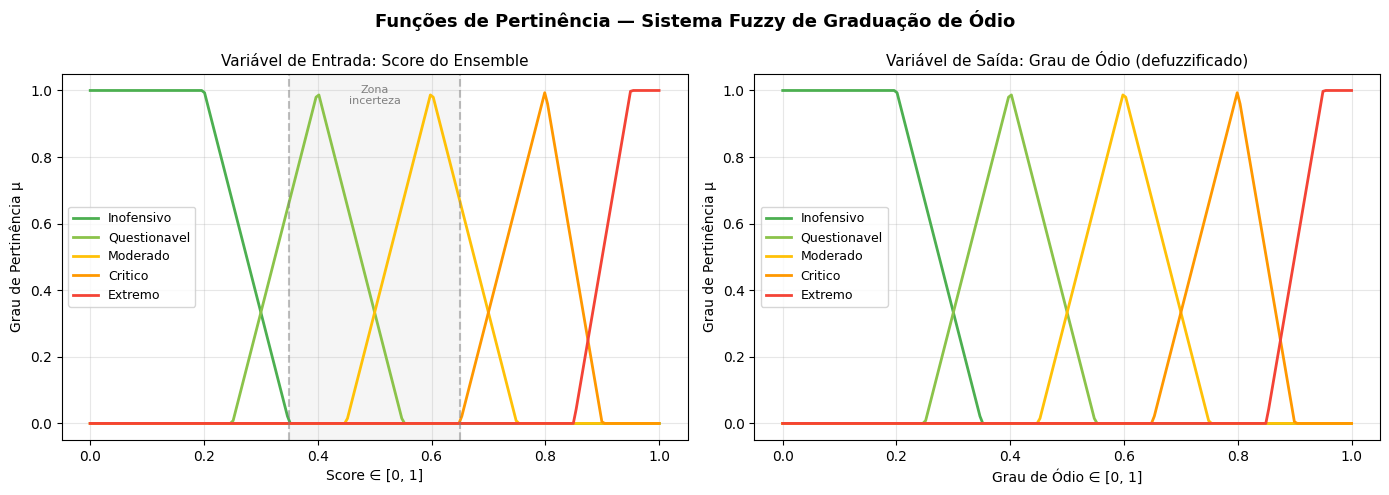

Figura salva em /content/drive/MyDrive/hateful_memes/outputs/fuzzy_mf.png
✅ Sistema fuzzy pronto


In [38]:
class FuzzyHateGrader:
    """
    Converte o score do ensemble (∈ [0,1]) em um grau contínuo de ódio
    usando lógica fuzzy Mamdani com defuzzificação por centroide.
    """
    def __init__(self):
        self._build_system()

    def _build_system(self):
        score_universe = np.linspace(0, 1, 200)
        hate_universe  = np.linspace(0, 1, 200)

        self.score_var = ctrl.Antecedent(score_universe, 'score')
        self.score_var['inofensivo']   = fuzz.trapmf(score_universe, [0.0, 0.0, 0.2, 0.35])
        self.score_var['questionavel'] = fuzz.trimf(score_universe, [0.25, 0.40, 0.55])
        self.score_var['moderado']     = fuzz.trimf(score_universe, [0.45, 0.60, 0.75])
        self.score_var['critico']      = fuzz.trimf(score_universe, [0.65, 0.80, 0.90])
        self.score_var['extremo']      = fuzz.trapmf(score_universe, [0.85, 0.95, 1.0, 1.0])

        self.grade_var = ctrl.Consequent(hate_universe, 'grau_odio')
        self.grade_var['inofensivo']   = fuzz.trapmf(hate_universe, [0.0, 0.0, 0.2, 0.35])
        self.grade_var['questionavel'] = fuzz.trimf(hate_universe, [0.25, 0.40, 0.55])
        self.grade_var['moderado']     = fuzz.trimf(hate_universe, [0.45, 0.60, 0.75])
        self.grade_var['critico']      = fuzz.trimf(hate_universe, [0.65, 0.80, 0.90])
        self.grade_var['extremo']      = fuzz.trapmf(hate_universe, [0.85, 0.95, 1.0, 1.0])

        rules = [
            ctrl.Rule(self.score_var['inofensivo'],   self.grade_var['inofensivo']),
            ctrl.Rule(self.score_var['questionavel'], self.grade_var['questionavel']),
            ctrl.Rule(self.score_var['moderado'],     self.grade_var['moderado']),
            ctrl.Rule(self.score_var['critico'],      self.grade_var['critico']),
            ctrl.Rule(self.score_var['extremo'],      self.grade_var['extremo']),
        ]
        self.hate_ctrl = ctrl.ControlSystem(rules)
        self.simulator = ctrl.ControlSystemSimulation(self.hate_ctrl)

    def compute(self, ensemble_score: float) -> dict:
        score_clipped = float(np.clip(ensemble_score, 0.001, 0.999))
        self.simulator.input['score'] = score_clipped
        self.simulator.compute()
        grau = float(self.simulator.output['grau_odio'])

        su = self.score_var.universe
        pertinencias = {
            k: float(fuzz.interp_membership(su, self.score_var[k].mf, score_clipped))
            for k in ['inofensivo', 'questionavel', 'moderado', 'critico', 'extremo']
        }
        return {
            'grau_odio'  : round(grau, 4),
            'categoria'  : max(pertinencias, key=pertinencias.get),
            'pertinencias': {k: round(v, 4) for k, v in pertinencias.items()}
        }

    def plot_membership_functions(self):
        """Visualiza as funções de pertinência — útil para documentar no TCC."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Funções de Pertinência — Sistema Fuzzy de Graduação de Ódio',
                     fontsize=13, fontweight='bold')

        colors_in = {'inofensivo': '#4CAF50',
                     'questionavel': '#8BC34A',
                     'moderado': '#FFC107',
                     'critico': '#FF9800',
                     'extremo': '#F44336'}

        ax = axes[0]
        for label, color in colors_in.items():
            ax.plot(self.score_var.universe, self.score_var[label].mf,
                    label=label.replace('_', ' ').title(), color=color, linewidth=2)
        ax.axvspan(0.35, 0.65, alpha=0.08, color='gray')
        ax.axvline(0.35, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0.65, color='gray', linestyle='--', alpha=0.5)
        ax.text(0.50, 0.97, 'Zona\nincerteza', ha='center', va='top',
                fontsize=8, color='gray', transform=ax.get_xaxis_transform())
        ax.set_title('Variável de Entrada: Score do Ensemble', fontsize=11)
        ax.set_xlabel('Score ∈ [0, 1]'); ax.set_ylabel('Grau de Pertinência μ')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        ax2 = axes[1]
        for label, color in colors_in.items():
            ax2.plot(self.grade_var.universe, self.grade_var[label].mf,
                     label=label.title(), color=color, linewidth=2)
        ax2.set_title('Variável de Saída: Grau de Ódio (defuzzificado)', fontsize=11)
        ax2.set_xlabel('Grau de Ódio ∈ [0, 1]'); ax2.set_ylabel('Grau de Pertinência μ')
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        save_path = os.path.join(Config.output_dir, 'fuzzy_mf.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Figura salva em {save_path}")


fuzzy_grader = FuzzyHateGrader()
fuzzy_grader.plot_membership_functions()
print("✅ Sistema fuzzy pronto")


### 3.5 HateSpeechPipeline — Integração Completa

In [44]:
class HateSpeechPipeline:
    """
    Pipeline completo: HateCLIPper + RGCL + IntMeme fallback + FuzzyGrader.

    Fluxo:
    1. Extrai embeddings CLIP (congelado)
    2. Classifica com HateCLIPper e RGCL → ensemble ponderado
    3. Se score incerto [uncertainty_low, uncertainty_high] → aciona IntMeme
    4. Score final → FuzzyGrader para graduação contínua
    """
    def __init__(self, hateclipper_model, rgcl_model, intmeme_model, fuzzy_grader,
                 w_clipper=0.55, w_rgcl=0.45,
                 uncertainty_low=0.35, uncertainty_high=0.65,
                 llm_weight=0.40):
        assert abs(w_clipper + w_rgcl - 1.0) < 1e-6, "Pesos do ensemble devem somar 1.0"
        self.hateclipper    = hateclipper_model
        self.rgcl           = rgcl_model
        self.intmeme        = intmeme_model
        self.fuzzy          = fuzzy_grader
        self.w_clipper      = w_clipper
        self.w_rgcl         = w_rgcl
        self.uncertainty_low  = uncertainty_low
        self.uncertainty_high = uncertainty_high
        self.llm_weight     = llm_weight
        self.decision_log   = []

    def _is_uncertain(self, score: float) -> bool:
        return self.uncertainty_low < score < self.uncertainty_high

    @torch.no_grad()
    def predict(self, pixel_values, input_ids, attention_mask,
                raw_texts=None, return_details=False):
        self.hateclipper.eval()
        self.rgcl.eval()

        visual_emb, text_emb = extract_clip_features(pixel_values, input_ids, attention_mask)

        clipper_scores  = self.hateclipper(visual_emb, text_emb)
        rgcl_scores     = self.rgcl(visual_emb, text_emb)
        ensemble_scores = self.w_clipper * clipper_scores + self.w_rgcl * rgcl_scores

        predictions, details_list = [], []
        texts = raw_texts if raw_texts else [""] * visual_emb.shape[0]

        for i in range(visual_emb.shape[0]):
            s_clip = float(clipper_scores[i].cpu())
            s_rgcl = float(rgcl_scores[i].cpu())
            s_ens  = float(ensemble_scores[i].cpu())

            llm_invoked = False
            final_score = s_ens

            if self._is_uncertain(s_ens):
                llm_invoked = True
                llm_score   = float(
                    self.intmeme(visual_emb[i:i+1], text_emb[i:i+1],
                                 text_raw=texts[i]).cpu()
                )
                final_score = (1 - self.llm_weight) * s_ens + self.llm_weight * llm_score
            else:
                llm_score = None

            prediction   = int(final_score >= 0.5)
            fuzzy_result = self.fuzzy.compute(final_score)

            entry = {
                'text': texts[i][:80],
                'score_hateclipper': round(s_clip, 4),
                'score_rgcl'       : round(s_rgcl, 4),
                'score_ensemble'   : round(s_ens,  4),
                'llm_invoked'      : llm_invoked,
                'score_llm'        : round(llm_score, 4) if llm_score else None,
                'final_score'      : round(final_score, 4),
                'prediction'       : prediction,
                **{f'fuzzy_{k}': v for k, v in fuzzy_result.items()}
            }
            self.decision_log.append(entry)
            predictions.append(prediction)
            if return_details:
                details_list.append(entry)

        return (predictions, details_list) if return_details else predictions

    def get_decision_summary(self):
        if not self.decision_log:
            return "Nenhuma predição realizada ainda."
        n      = len(self.decision_log)
        n_llm  = sum(d['llm_invoked'] for d in self.decision_log)
        scores = [d['final_score'] for d in self.decision_log]
        return {
            'total_samples'   : n,
            'llm_invocations' : n_llm,
            'llm_rate'        : round(n_llm / n, 4),
            'hate_predictions': sum(d['prediction'] for d in self.decision_log),
            'mean_final_score': round(float(np.mean(scores)), 4),
            'std_final_score' : round(float(np.std(scores)),  4),
        }


pipeline_hate = HateSpeechPipeline(
    hateclipper_model=hateclipper,
    rgcl_model=rgcl,
    intmeme_model=intmeme,
    fuzzy_grader=fuzzy_grader,
    w_clipper=0.55, w_rgcl=0.45,
    uncertainty_low=0.35, uncertainty_high=0.65,
    llm_weight=0.40
)
print("✅ Pipeline instanciado")
print(f"   Pesos ensemble  : HateCLIPper={pipeline_hate.w_clipper}, RGCL={pipeline_hate.w_rgcl}")
print(f"   Zona de incerteza: [{pipeline_hate.uncertainty_low}, {pipeline_hate.uncertainty_high}]")

✅ Pipeline instanciado
   Pesos ensemble  : HateCLIPper=0.55, RGCL=0.45
   Zona de incerteza: [0.35, 0.65]


## <font color="orange">4. Treinamento</font>

O treinamento treina HateCLIPper e RGCL em paralelo (otimizadores independentes) com:
- **CosineAnnealingLR** para ambos os módulos
- **Early stopping** (paciência = 5 épocas sem melhoria no AUROC médio)
- **Checkpointing** automático — o treinamento pode ser retomado de onde parou

In [40]:
def train_pipeline(pipeline_obj, dl_train, dl_val,
                   n_epochs=Config.max_epochs, lr=Config.lr, resume=True):
    criterion = nn.BCELoss()

    opt_clipper   = torch.optim.AdamW(pipeline_obj.hateclipper.parameters(),
                                       lr=lr,       weight_decay=Config.weight_decay)
    opt_rgcl      = torch.optim.AdamW(pipeline_obj.rgcl.parameters(),
                                       lr=lr * 0.8, weight_decay=Config.weight_decay)
    sched_clipper = torch.optim.lr_scheduler.CosineAnnealingLR(opt_clipper, T_max=n_epochs)
    sched_rgcl    = torch.optim.lr_scheduler.CosineAnnealingLR(opt_rgcl,    T_max=n_epochs)

    history = {'train_loss_clip': [], 'train_loss_rgcl': [],
               'val_auroc_clip': [],  'val_auroc_rgcl': []}

    best_auroc       = 0.0
    patience_counter = 0
    PATIENCE         = 5
    start_epoch      = 1

    checkpoint_path = os.path.join(Config.output_dir, 'checkpoint.pt')
    best_path       = os.path.join(Config.output_dir, 'best_pipeline.pt')

    if resume and os.path.exists(checkpoint_path):
        print(f"Retomando de {checkpoint_path}")
        ckpt = torch.load(checkpoint_path, weights_only=False)
        pipeline_obj.hateclipper.load_state_dict(ckpt['hateclipper'])
        pipeline_obj.rgcl.load_state_dict(ckpt['rgcl'])
        opt_clipper.load_state_dict(ckpt['opt_clipper'])
        opt_rgcl.load_state_dict(ckpt['opt_rgcl'])
        sched_clipper.load_state_dict(ckpt['sched_clipper'])
        sched_rgcl.load_state_dict(ckpt['sched_rgcl'])
        start_epoch      = ckpt['epoch'] + 1
        best_auroc       = ckpt['best_auroc']
        patience_counter = ckpt['patience_counter']
        history          = ckpt['history']
        print(f"Continuando da época {start_epoch}")
        if start_epoch > n_epochs or patience_counter >= PATIENCE:
            print("Treinamento já concluído anteriormente.")
            return history

    print(f"Iniciando treinamento: {n_epochs} épocas, lr={lr}")
    print('─' * 70)

    for epoch in range(start_epoch, n_epochs + 1):
        pipeline_obj.hateclipper.train()
        pipeline_obj.rgcl.train()

        clip_loss_sum = rgcl_loss_sum = n_batches = 0

        for batch in dl_train:
            labels = batch['labels'].float().to(Config.device)
            with torch.no_grad():
                v_emb, t_emb = extract_clip_features(
                    batch['pixel_values'], batch['input_ids'], batch['attention_mask'])

            opt_clipper.zero_grad()
            loss_clip = criterion(pipeline_obj.hateclipper(v_emb, t_emb), labels)
            loss_clip.backward()
            torch.nn.utils.clip_grad_norm_(pipeline_obj.hateclipper.parameters(), Config.grad_clip)
            opt_clipper.step()

            opt_rgcl.zero_grad()
            loss_rgcl = criterion(pipeline_obj.rgcl(v_emb, t_emb), labels)
            loss_rgcl.backward()
            torch.nn.utils.clip_grad_norm_(pipeline_obj.rgcl.parameters(), Config.grad_clip)
            opt_rgcl.step()

            clip_loss_sum += loss_clip.item()
            rgcl_loss_sum += loss_rgcl.item()
            n_batches     += 1

        sched_clipper.step(); sched_rgcl.step()

        val_labels, val_sc, val_sr = [], [], []
        with torch.no_grad():
            for batch in dl_val:
                v_emb, t_emb = extract_clip_features(
                    batch['pixel_values'], batch['input_ids'], batch['attention_mask'])
                val_labels.extend(batch['labels'].float().cpu().tolist())
                val_sc.extend(pipeline_obj.hateclipper(v_emb, t_emb).cpu().tolist())
                val_sr.extend(pipeline_obj.rgcl(v_emb, t_emb).cpu().tolist())

        try:
            auroc_c = roc_auc_score(val_labels, val_sc)
            auroc_r = roc_auc_score(val_labels, val_sr)
        except ValueError:
            auroc_c = auroc_r = 0.5

        avg_auroc = (auroc_c + auroc_r) / 2
        history['train_loss_clip'].append(clip_loss_sum / max(n_batches,1))
        history['train_loss_rgcl'].append(rgcl_loss_sum / max(n_batches,1))
        history['val_auroc_clip'].append(auroc_c)
        history['val_auroc_rgcl'].append(auroc_r)

        print(f"Ép {epoch:2d}/{n_epochs} | "
              f"Loss Clip={clip_loss_sum/max(n_batches,1):.4f} "
              f"RGCL={rgcl_loss_sum/max(n_batches,1):.4f} | "
              f"AUROC Clip={auroc_c:.4f} RGCL={auroc_r:.4f}", end='')

        if avg_auroc > best_auroc:
            best_auroc = avg_auroc; patience_counter = 0
            torch.save({'hateclipper': pipeline_obj.hateclipper.state_dict(),
                        'rgcl': pipeline_obj.rgcl.state_dict(),
                        'epoch': epoch, 'best_auroc': best_auroc}, best_path)
            print(" ★ novo melhor")
        else:
            patience_counter += 1
            print(f" (paciência {patience_counter}/{PATIENCE})")

        torch.save({'hateclipper': pipeline_obj.hateclipper.state_dict(),
                    'rgcl': pipeline_obj.rgcl.state_dict(),
                    'opt_clipper': opt_clipper.state_dict(),
                    'opt_rgcl': opt_rgcl.state_dict(),
                    'sched_clipper': sched_clipper.state_dict(),
                    'sched_rgcl': sched_rgcl.state_dict(),
                    'epoch': epoch, 'best_auroc': best_auroc,
                    'patience_counter': patience_counter, 'history': history}, checkpoint_path)

        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping na época {epoch}."); break

    print(f"\n✅ Melhor AUROC médio: {best_auroc:.4f}")
    return history

print("✅ Função train_pipeline definida (com checkpoint e early stopping)")

✅ Função train_pipeline definida (com checkpoint e early stopping)


In [41]:
torch.serialization.add_safe_globals([
    np._core.multiarray.scalar,
    np.dtype,
    np.dtypes.Float64DType
])

best_model_path = os.path.join(Config.output_dir, 'best_pipeline.pt')

if os.path.exists(best_model_path):
    print(f"Modelo já treinado encontrado em {best_model_path}. Carregando pesos...")
    checkpoint = torch.load(best_model_path, weights_only=False)
    pipeline_hate.hateclipper.load_state_dict(checkpoint['hateclipper'])
    pipeline_hate.rgcl.load_state_dict(checkpoint['rgcl'])
    print("✅ Pesos carregados com sucesso!")
else:
    print("Iniciando/retomando treinamento...")
    history = train_pipeline(
        pipeline_hate, dl_train, dl_dev_seen,
        n_epochs=Config.max_epochs, lr=Config.lr, resume=True
    )

Iniciando/retomando treinamento...
Iniciando treinamento: 20 épocas, lr=0.0001
──────────────────────────────────────────────────────────────────────
Ép  1/20 | Loss Clip=0.6158 RGCL=0.4901 | AUROC Clip=0.6106 RGCL=0.7487 ★ novo melhor
Ép  2/20 | Loss Clip=0.5628 RGCL=0.3937 | AUROC Clip=0.6485 RGCL=0.7609 ★ novo melhor
Ép  3/20 | Loss Clip=0.5382 RGCL=0.3144 | AUROC Clip=0.6383 RGCL=0.7725 ★ novo melhor
Ép  4/20 | Loss Clip=0.5182 RGCL=0.2268 | AUROC Clip=0.6602 RGCL=0.7942 ★ novo melhor
Ép  5/20 | Loss Clip=0.5011 RGCL=0.1477 | AUROC Clip=0.6397 RGCL=0.7857 (paciência 1/5)
Ép  6/20 | Loss Clip=0.4904 RGCL=0.0959 | AUROC Clip=0.6576 RGCL=0.7972 ★ novo melhor
Ép  7/20 | Loss Clip=0.4817 RGCL=0.0709 | AUROC Clip=0.6625 RGCL=0.7947 ★ novo melhor
Ép  8/20 | Loss Clip=0.4692 RGCL=0.0465 | AUROC Clip=0.6536 RGCL=0.8031 (paciência 1/5)
Ép  9/20 | Loss Clip=0.4637 RGCL=0.0305 | AUROC Clip=0.6651 RGCL=0.7972 ★ novo melhor
Ép 10/20 | Loss Clip=0.4502 RGCL=0.0156 | AUROC Clip=0.6533 RGCL=0.7944 

## <font color="orange">5. Avaliação</font>

Iniciando avaliação...
═══════════════════════════════════════════════════════
RESULTADO DA AVALIAÇÃO DO PIPELINE
═══════════════════════════════════════════════════════
Amostras      : 1000
Accuracy      : 0.7150
F1 (macro)    : 0.7076
F1 (weighted) : 0.7085
AUC-ROC       : 0.7828
───────────────────────────────────────────────────────
Taxa LLM      : 20.70% (207/1000)
Score médio   : 0.3387 ± 0.3149
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Não-ódio       0.67      0.86      0.75       510
        Ódio       0.79      0.57      0.66       490

    accuracy                           0.71      1000
   macro avg       0.73      0.71      0.71      1000
weighted avg       0.73      0.71      0.71      1000



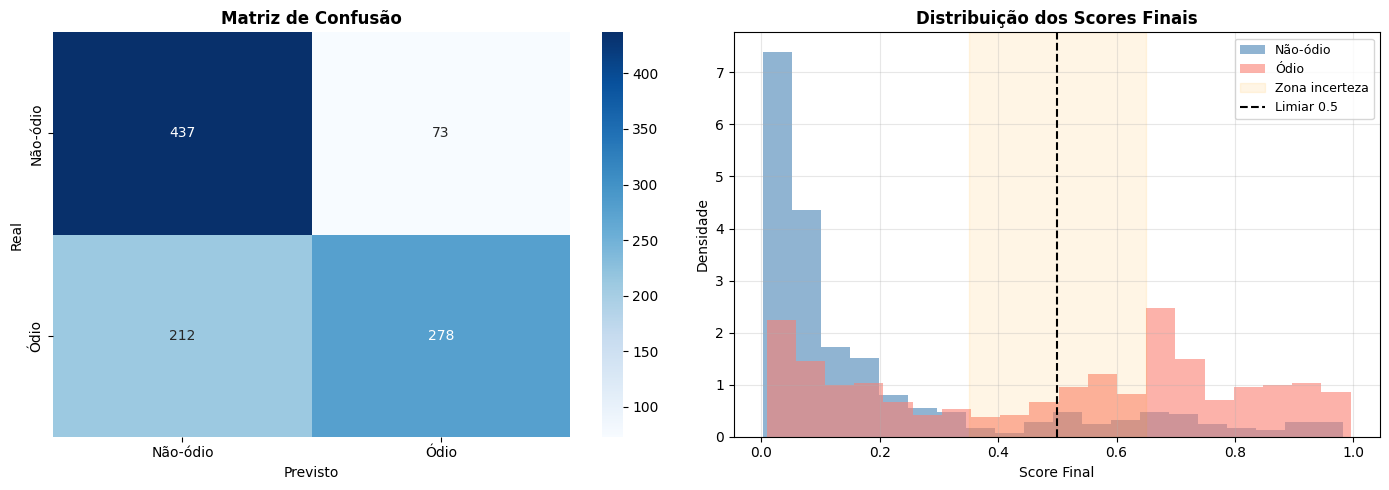

Gráficos salvos em: /content/drive/MyDrive/hateful_memes/outputs/evaluation_plots.png


In [45]:
def evaluate_pipeline(pipeline_obj, dataloader, verbose=True):
    """Avalia o pipeline completo e gera métricas + gráficos."""
    y_true, y_pred, all_details = [], [], []
    pipeline_obj.decision_log = []

    print("Iniciando avaliação...")
    for batch in dataloader:
        preds, details = pipeline_obj.predict(
            pixel_values=batch['pixel_values'],
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            return_details=True
        )
        y_true.extend(batch['labels'].cpu().tolist())
        y_pred.extend(preds)
        all_details.extend(details)

    acc  = accuracy_score(y_true, y_pred)
    f1_m = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    try:
        auroc = roc_auc_score(y_true, [d['final_score'] for d in all_details])
    except ValueError:
        auroc = float('nan')

    cm = confusion_matrix(y_true, y_pred)

    if verbose:
        print('═' * 55)
        print('RESULTADO DA AVALIAÇÃO DO PIPELINE')
        print('═' * 55)
        print(f'Amostras      : {len(y_true)}')
        print(f'Accuracy      : {acc:.4f}')
        print(f'F1 (macro)    : {f1_m:.4f}')
        print(f'F1 (weighted) : {f1_w:.4f}')
        print(f'AUC-ROC       : {auroc:.4f}')
        print('─' * 55)
        summary = pipeline_obj.get_decision_summary()
        print(f'Taxa LLM      : {summary["llm_rate"]:.2%} ({summary["llm_invocations"]}/{summary["total_samples"]})')
        print(f'Score médio   : {summary["mean_final_score"]:.4f} ± {summary["std_final_score"]:.4f}')
        print('─' * 55)
        print(classification_report(y_true, y_pred,
                                    target_names=['Não-ódio', 'Ódio'], zero_division=0))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Não-ódio','Ódio'],
                    yticklabels=['Não-ódio','Ódio'], ax=axes[0])
        axes[0].set_title('Matriz de Confusão', fontweight='bold')
        axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')

        scores_hate   = [d['final_score'] for d, t in zip(all_details, y_true) if t == 1]
        scores_benign = [d['final_score'] for d, t in zip(all_details, y_true) if t == 0]
        axes[1].hist(scores_benign, bins=20, alpha=0.6, color='steelblue', label='Não-ódio', density=True)
        axes[1].hist(scores_hate,   bins=20, alpha=0.6, color='salmon',    label='Ódio',     density=True)
        axes[1].axvspan(0.35, 0.65, alpha=0.1, color='orange', label='Zona incerteza')
        axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar 0.5')
        axes[1].set_xlabel('Score Final'); axes[1].set_ylabel('Densidade')
        axes[1].set_title('Distribuição dos Scores Finais', fontweight='bold')
        axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        save_path = os.path.join(Config.output_dir, 'evaluation_plots.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Gráficos salvos em: {save_path}")

    return {'accuracy': acc, 'f1_macro': f1_m, 'f1_weighted': f1_w,
            'auroc': auroc, 'confusion_matrix': cm, 'details': all_details}


results = evaluate_pipeline(pipeline_hate, dl_test_seen)

Executando análise de ablação...
HateCLIPper                    | Acc=0.5980 | F1=0.5594 | AUC=0.6943
RGCL                           | Acc=0.7350 | F1=0.7296 | AUC=0.7933
Ensemble (sem LLM)             | Acc=0.7090 | F1=0.6994 | AUC=0.7840
Pipeline Completo              | Acc=0.7150 | F1=0.7076 | AUC=0.7828


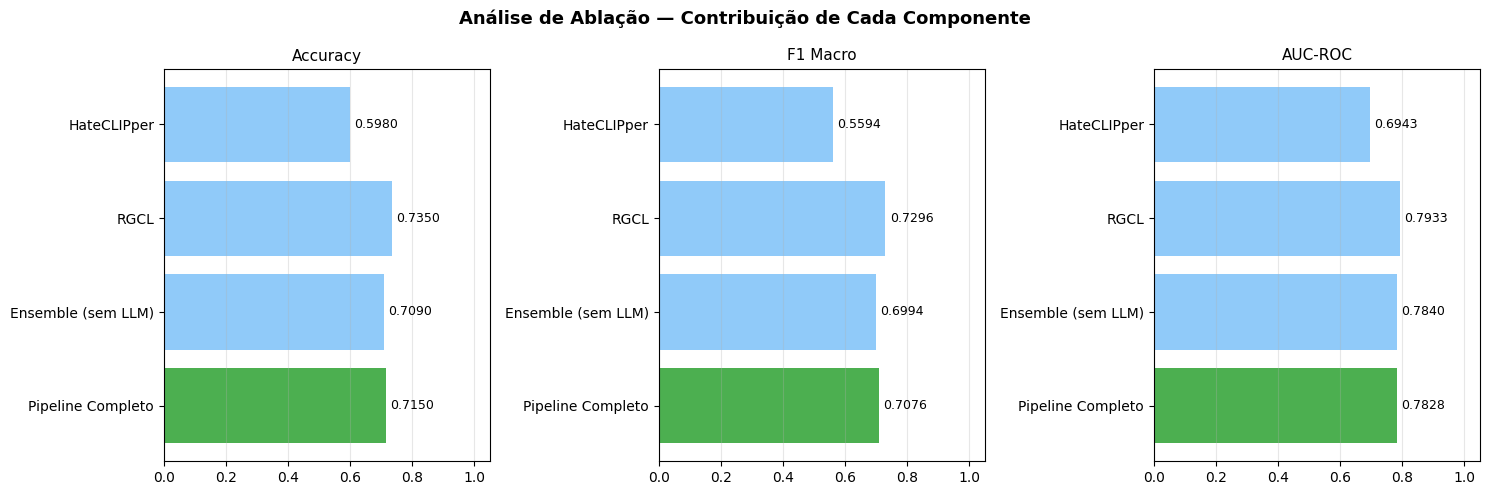

In [46]:
def ablation_study(pipeline_obj, dataloader):
    """
    Compara variantes abladas do pipeline para identificar a contribuição
    de cada componente (HateCLIPper, RGCL, LLM fallback).
    """
    configs = [
        {'name': 'HateCLIPper',     'w_clip': 1.0,  'w_rgcl': 0.0,  'llm_low': -1,   'llm_high': -1},
        {'name': 'RGCL',            'w_clip': 0.0,  'w_rgcl': 1.0,  'llm_low': -1,   'llm_high': -1},
        {'name': 'Ensemble (sem LLM)', 'w_clip': 0.55, 'w_rgcl': 0.45, 'llm_low': -1,   'llm_high': -1},
        {'name': 'Pipeline Completo',  'w_clip': 0.55, 'w_rgcl': 0.45, 'llm_low': 0.35, 'llm_high': 0.65},
    ]
    ablation_results = []
    print('Executando análise de ablação...')

    for cfg in configs:
        pipeline_obj.w_clipper        = cfg['w_clip']
        pipeline_obj.w_rgcl           = cfg['w_rgcl']
        pipeline_obj.uncertainty_low  = cfg['llm_low']
        pipeline_obj.uncertainty_high = cfg['llm_high']
        pipeline_obj.decision_log     = []

        y_true, y_pred, scores = [], [], []
        for batch in dataloader:
            preds, details = pipeline_obj.predict(
                pixel_values=batch['pixel_values'],
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                return_details=True
            )
            y_true.extend(batch['labels'].cpu().tolist())
            y_pred.extend(preds)
            scores.extend([d['final_score'] for d in details])

        acc  = accuracy_score(y_true, y_pred)
        f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)
        try:    auroc = roc_auc_score(y_true, scores)
        except: auroc = float('nan')

        ablation_results.append({'Configuração': cfg['name'],
                                  'Accuracy': round(acc,4),
                                  'F1 Macro': round(f1_m,4),
                                  'AUC-ROC': round(auroc,4)})
        print(f"{cfg['name']:30s} | Acc={acc:.4f} | F1={f1_m:.4f} | AUC={auroc:.4f}")

    pipeline_obj.w_clipper=0.55; pipeline_obj.w_rgcl=0.45
    pipeline_obj.uncertainty_low=0.35; pipeline_obj.uncertainty_high=0.65

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Análise de Ablação — Contribuição de Cada Componente',
                 fontsize=13, fontweight='bold')
    colors = ['#4CAF50' if r['Configuração']=='Pipeline Completo' else '#90CAF9'
              for r in ablation_results]

    for ax, metric in zip(axes, ['Accuracy', 'F1 Macro', 'AUC-ROC']):
        bars = ax.barh([r['Configuração'] for r in ablation_results],
                       [r[metric] for r in ablation_results], color=colors)
        ax.set_xlim(0, 1.05); ax.set_title(metric, fontsize=11)
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.grid(True, axis='x', alpha=0.3); ax.invert_yaxis()

    plt.tight_layout()
    save_path = os.path.join(Config.output_dir, 'ablation_study.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return ablation_results

ablation_results = ablation_study(pipeline_hate, dl_test_seen)

Otimizando pesos do ensemble (val set)...
✅ Melhores pesos: w_clipper=0.10, w_rgcl=0.90
   Melhor f1_macro: 0.6831


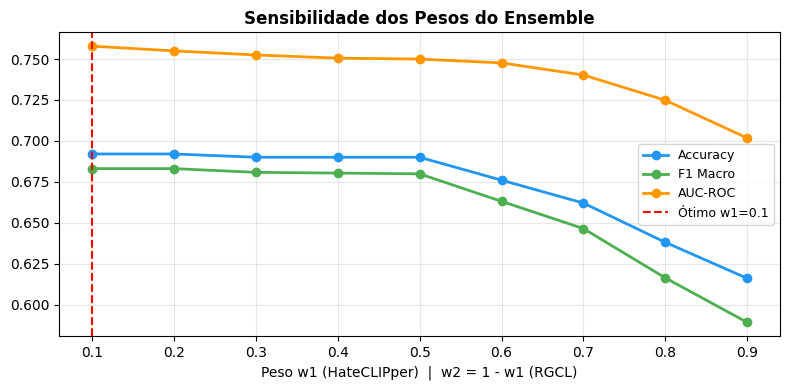

In [47]:
def optimize_ensemble_weights(pipeline_obj, dataloader, metric='f1_macro'):
    """
    Grid search nos pesos w1 (HateCLIPper) e w2 = 1-w1 (RGCL)
    para maximizar a métrica no conjunto de validação.
    metric: 'accuracy' | 'f1_macro' | 'auroc'
    """
    best_score, best_w1, results_grid = -1, 0.5, []

    for w1 in np.arange(0.1, 1.0, 0.1):
        w2 = round(1.0 - w1, 2)
        pipeline_obj.w_clipper = round(w1, 2); pipeline_obj.w_rgcl = w2
        pipeline_obj.decision_log = []

        y_true, y_pred, scores = [], [], []
        for batch in dataloader:
            preds, details = pipeline_obj.predict(
                pixel_values=batch['pixel_values'],
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                return_details=True)
            y_true.extend(batch['labels'].cpu().tolist())
            y_pred.extend(preds)
            scores.extend([d['final_score'] for d in details])

        acc = accuracy_score(y_true, y_pred)
        f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
        try: auc = roc_auc_score(y_true, scores)
        except: auc = 0.5

        mv = {'accuracy': acc, 'f1_macro': f1m, 'auroc': auc}[metric]
        results_grid.append({'w_clipper': round(w1,2), 'w_rgcl': w2,
                              'accuracy': acc, 'f1_macro': f1m, 'auroc': auc})
        if mv > best_score: best_score = mv; best_w1 = round(w1,2)

    pipeline_obj.w_clipper = best_w1
    pipeline_obj.w_rgcl    = round(1.0 - best_w1, 2)

    print(f"✅ Melhores pesos: w_clipper={best_w1:.2f}, w_rgcl={1-best_w1:.2f}")
    print(f"   Melhor {metric}: {best_score:.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    w1_vals = [r['w_clipper'] for r in results_grid]
    for m, color, label in [('accuracy','#2196F3','Accuracy'),('f1_macro','#4CAF50','F1 Macro'),('auroc','#FF9800','AUC-ROC')]:
        ax.plot(w1_vals, [r[m] for r in results_grid], marker='o', color=color, label=label, lw=2)
    ax.axvline(best_w1, color='red', linestyle='--', label=f'Ótimo w1={best_w1}')
    ax.set_xlabel('Peso w1 (HateCLIPper)  |  w2 = 1 - w1 (RGCL)')
    ax.set_title('Sensibilidade dos Pesos do Ensemble', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = os.path.join(Config.output_dir, 'weight_optimization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return results_grid, best_w1

print("Otimizando pesos do ensemble (val set)...")
grid_results, best_w = optimize_ensemble_weights(pipeline_hate, dl_dev_seen, metric='f1_macro')

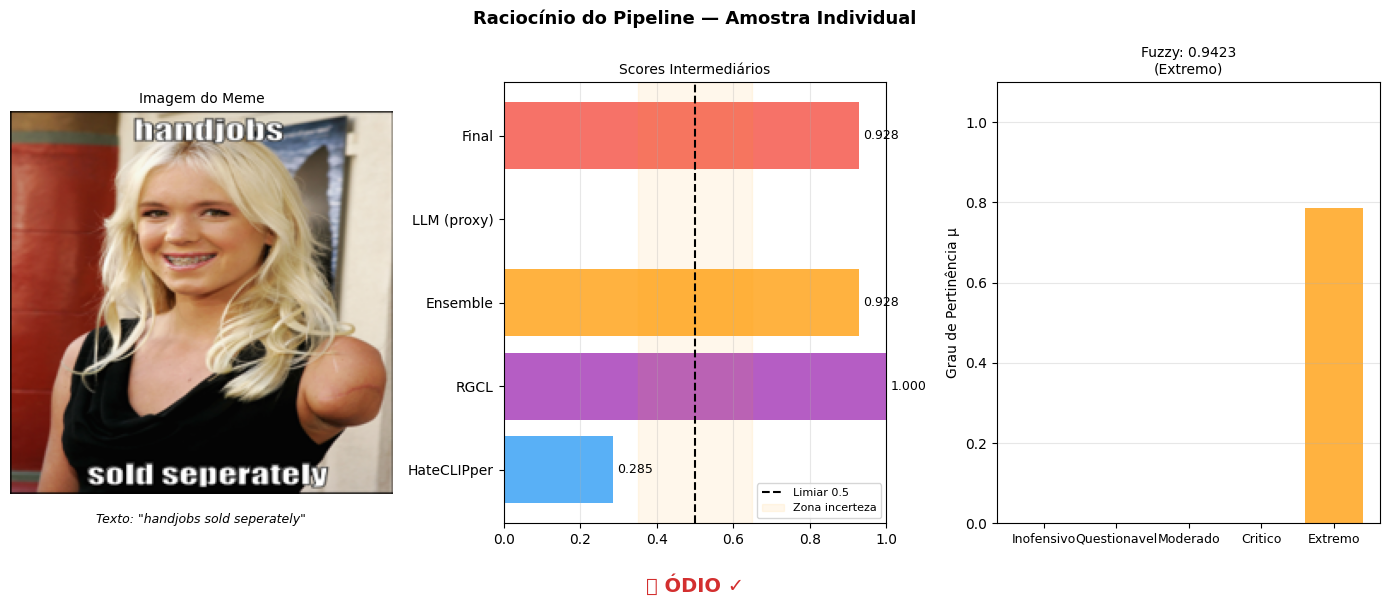

{
  "text": "handjobs sold seperately",
  "score_hateclipper": 0.285,
  "score_rgcl": 1.0,
  "score_ensemble": 0.9285,
  "llm_invoked": false,
  "score_llm": null,
  "final_score": 0.9285,
  "prediction": 1,
  "fuzzy_grau_odio": 0.9423,
  "fuzzy_categoria": "extremo"
}


In [48]:
def visualize_prediction(pipeline_obj, sample):
    """
    Exibe o raciocínio completo do pipeline para uma amostra:
    imagem, scores intermediários e graduação fuzzy.
    """
    batch = prep([sample])
    preds, details = pipeline_obj.predict(
        pixel_values=batch['pixel_values'],
        input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'],
        raw_texts=[sample['text']], return_details=True)

    pred    = preds[0]
    detail  = details[0]
    true_lbl= sample.get('label', None)

    fig = plt.figure(figsize=(14, 6))
    fig.suptitle('Raciocínio do Pipeline — Amostra Individual', fontsize=13, fontweight='bold')

    ax_img = fig.add_subplot(1, 3, 1)
    ax_img.imshow(sample['image']); ax_img.axis('off')
    ax_img.set_title('Imagem do Meme', fontsize=10)
    txt = sample['text']; txt_short = f'"{txt[:50]}..."' if len(txt)>50 else f'"{txt}"'
    ax_img.text(0.5, -0.05, f'Texto: {txt_short}', ha='center', va='top', fontsize=9,
                transform=ax_img.transAxes, style='italic')

    ax_s = fig.add_subplot(1, 3, 2)
    slabels = ['HateCLIPper', 'RGCL', 'Ensemble', 'LLM (proxy)', 'Final']
    svals   = [detail['score_hateclipper'], detail['score_rgcl'],
               detail['score_ensemble'],
               detail['score_llm'] if detail['score_llm'] is not None else np.nan,
               detail['final_score']]
    bars = ax_s.barh(slabels, svals, color=['#2196F3','#9C27B0','#FF9800','#795548','#F44336'], alpha=0.75)
    ax_s.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Limiar 0.5')
    ax_s.axvspan(0.35, 0.65, alpha=0.08, color='orange', label='Zona incerteza')
    ax_s.set_xlim(0, 1); ax_s.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax_s.set_title('Scores Intermediários', fontsize=10)
    ax_s.legend(fontsize=8); ax_s.grid(True, axis='x', alpha=0.3)

    ax_f = fig.add_subplot(1, 3, 3)
    pert = detail['fuzzy_pertinencias']
    ax_f.bar(range(len(pert)), list(pert.values()),
             color=['#2196F3','#FF9800','#F44336'], alpha=0.75)
    ax_f.set_xticks(range(len(pert)))
    ax_f.set_xticklabels([k.replace('_','\n').title() for k in pert], fontsize=9)
    ax_f.set_ylim(0, 1.1); ax_f.set_ylabel('Grau de Pertinência μ')
    ax_f.set_title(f'Fuzzy: {detail["fuzzy_grau_odio"]:.4f}\n({detail["fuzzy_categoria"].replace("_"," ").title()})', fontsize=10)
    ax_f.grid(True, axis='y', alpha=0.3)

    label_str = 'ÓDIO' if pred == 1 else 'Não-ódio'
    if true_lbl is not None: label_str += ' ✓' if pred == true_lbl else ' ✗'
    if detail['llm_invoked']: label_str += ' (LLM acionado)'

    fig.text(0.5, 0.01, label_str, ha='center', fontsize=14, fontweight='bold',
             color='#D32F2F' if pred==1 else '#2E7D32')
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    save_path = os.path.join(Config.output_dir, 'sample_visualization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(json.dumps({k: v for k, v in detail.items() if k != 'fuzzy_pertinencias'},
                     indent=2, ensure_ascii=False))
    return detail

sample_demo = ds_test_seen[0]
detail_demo = visualize_prediction(pipeline_hate, sample_demo)

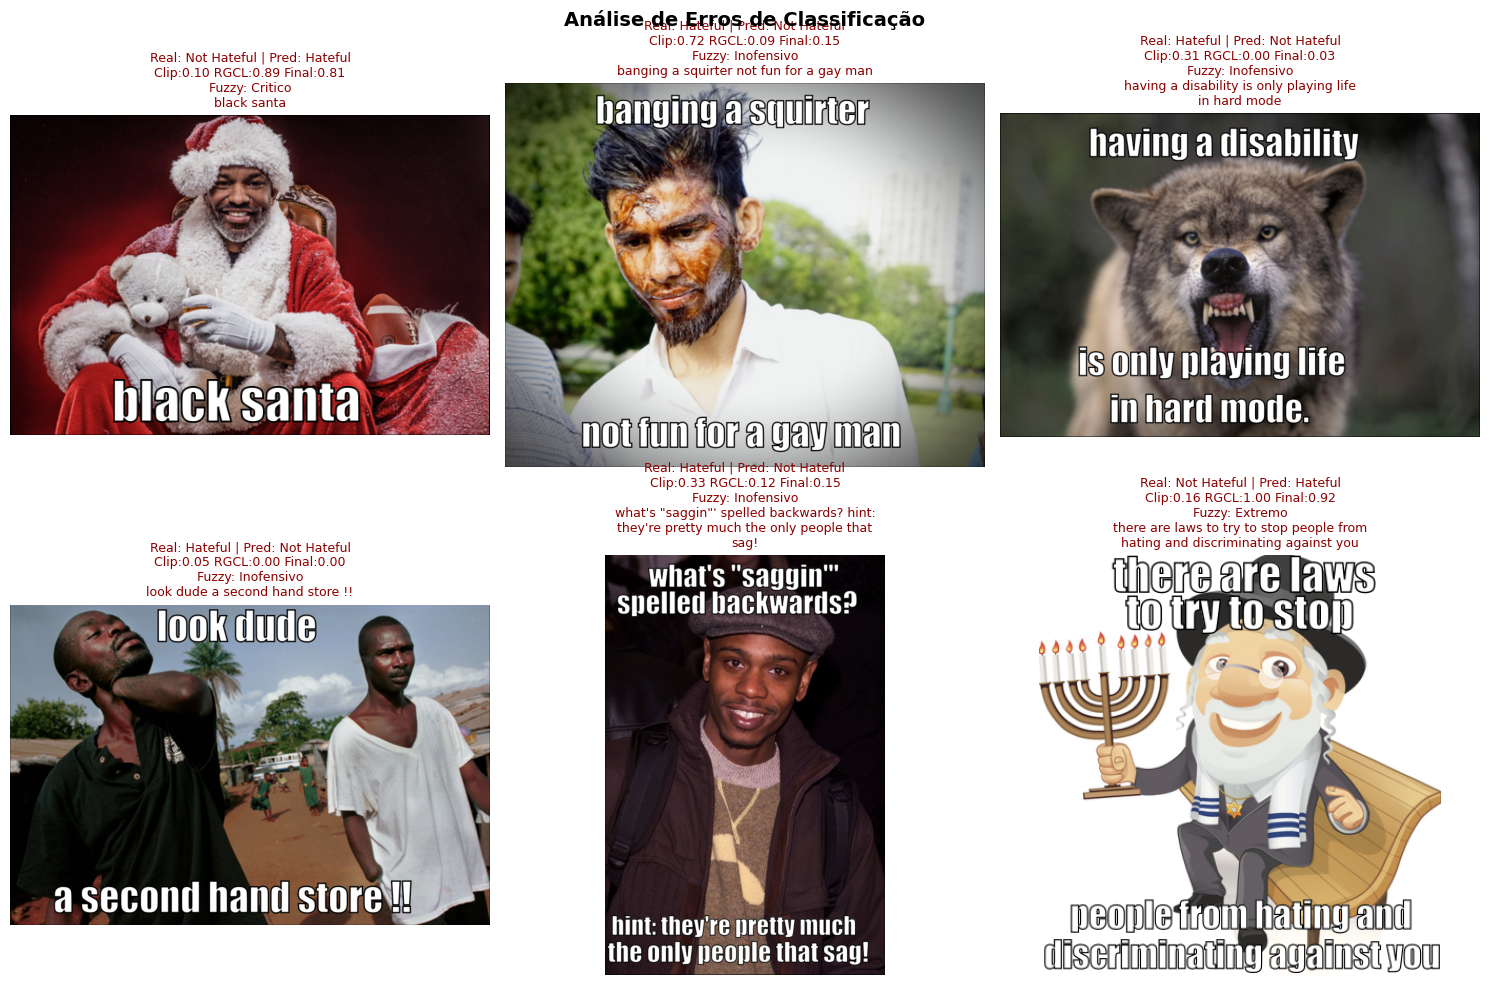

Gráfico salvo em: /content/drive/MyDrive/hateful_memes/outputs/misclassified_analysis.png


In [49]:
import textwrap

def show_misclassified(pipeline_obj, dataloader, df_ref, n=6):
    """
    Mostra os memes incorretamente classificados com detalhe de scores.
    Útil para análise qualitativa dos erros do modelo.
    """
    y_true, y_pred, all_details, all_ids = [], [], [], []

    for batch in dataloader:
        preds, details = pipeline_obj.predict(
            pixel_values=batch['pixel_values'],
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            return_details=True)
        y_true.extend(batch['labels'].cpu().tolist())
        y_pred.extend(preds)
        all_details.extend(details)
        all_ids.extend(batch['ids'])

    wrong_idx = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]
    if not wrong_idx:
        print("Nenhuma classificação incorreta encontrada!"); return

    sampled = random.sample(wrong_idx, min(n, len(wrong_idx)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Análise de Erros de Classificação', fontsize=14, fontweight='bold')

    for ax, idx in zip(axes.flat, sampled):
        meme_id = all_ids[idx]
        row = df_ref[df_ref['id'].astype(int) == int(meme_id)]
        if row.empty: ax.axis('off'); continue
        row = row.iloc[0]
        try:
            img = Image.open(os.path.join(base_path, row['img'])).convert('RGB')
            ax.imshow(img)
        except: ax.axis('off'); continue

        detail = all_details[idx]
        pred_lbl = "Hateful" if y_pred[idx]==1 else "Not Hateful"
        real_lbl = "Hateful" if y_true[idx]==1 else "Not Hateful"
        title = (f"Real: {real_lbl} | Pred: {pred_lbl}\n"
                 f"Clip:{detail['score_hateclipper']:.2f} "
                 f"RGCL:{detail['score_rgcl']:.2f} "
                 f"Final:{detail['final_score']:.2f}\n"
                 f"Fuzzy: {detail['fuzzy_categoria'].replace('_',' ').title()}\n"
                 + textwrap.fill(row['text'], width=42))
        ax.set_title(title, fontsize=9, color='darkred' if y_pred[idx]!=y_true[idx] else 'black')
        ax.axis('off')

    for i in range(len(sampled), len(axes.flat)):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()
    save_path = os.path.join(Config.output_dir, 'misclassified_analysis.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gráfico salvo em: {save_path}")

show_misclassified(pipeline_hate, dl_test_seen, df_test_seen)

In [50]:
final_model_path = os.path.join(Config.output_dir, 'pipeline_final.pt')
log_path         = os.path.join(Config.output_dir, 'decision_log.json')
report_path      = os.path.join(Config.output_dir, 'relatorio_tcc.txt')

torch.save({
    'hateclipper_state': pipeline_hate.hateclipper.state_dict(),
    'rgcl_state'       : pipeline_hate.rgcl.state_dict(),
    'pipeline_config'  : {
        'w_clipper'      : pipeline_hate.w_clipper,
        'w_rgcl'         : pipeline_hate.w_rgcl,
        'uncertainty_low': pipeline_hate.uncertainty_low,
        'uncertainty_high': pipeline_hate.uncertainty_high,
        'llm_weight'     : pipeline_hate.llm_weight,
        'clip_model'     : Config.clip_model,
    },
    'ablation_results' : ablation_results,
    'decision_log'     : pipeline_hate.decision_log,
}, final_model_path)

with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(pipeline_hate.decision_log, f, indent=2, ensure_ascii=False)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("  RESULTADOS — TCC: Discurso de Ódio em Memes\n")
    f.write("  Pipeline: HateCLIPper + RGCL + IntMeme + Fuzzy\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Modelo CLIP : {Config.clip_model}\n")
    f.write(f"Fusão       : {Config.fusion}\n")
    f.write(f"Dataset     : Hateful Memes Challenge (Facebook AI)\n\n")
    f.write("── Resultado Principal (test_seen) ─────────────────\n")
    f.write(f"  Accuracy  : {results['accuracy']:.4f}\n")
    f.write(f"  F1 (macro): {results['f1_macro']:.4f}\n")
    f.write(f"  AUC-ROC   : {results['auroc']:.4f}\n\n")
    f.write("── Ablação ─────────────────────────────────────────\n")
    for r in ablation_results:
        f.write(f"  {r['Configuração']:<28}: Acc={r['Accuracy']:.4f}  "
                f"F1={r['F1 Macro']:.4f}  AUC={r['AUC-ROC']:.4f}\n")

print(f"✅ Artefatos salvos em {Config.output_dir}")

✅ Artefatos salvos em /content/drive/MyDrive/hateful_memes/outputs


## <font color="orange">6. Demo</font>

In [52]:
!pip install --upgrade google-cloud-vision -q
!pip install deep-translator -q
!pip install gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.1/543.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.0 MB/s eta 0:00:00


In [ ]:
import io
import tempfile
import gradio as gr
from google.cloud import vision
from google.colab import userdata
from deep_translator import GoogleTranslator

gr.close_all()

try:
    key_json = userdata.get('GOOGLE_CLOUD_KEY')
    if key_json:
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
            f.write(key_json)
            os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = f.name
except Exception as e:
    print("Aviso: Chave GOOGLE_CLOUD_KEY não encontrada nos Secrets do Colab.", e)

try:
    vision_client = vision.ImageAnnotatorClient()
except Exception as e:
    print("Aviso: Falha ao inicializar o Vision API.", e)
    vision_client = None


def _extract_text_from_image(image):
    """Extrai texto do meme via Google Cloud Vision OCR."""
    if vision_client:
        try:
            byte_array = io.BytesIO()
            image.save(byte_array, format='PNG')
            vision_image = vision.Image(content=byte_array.getvalue())
            response = vision_client.text_detection(image=vision_image)
            texts = response.text_annotations
            if not response.error.message and texts:
                return texts[0].description.replace('\n', ' ').strip()
        except Exception as e:
            print(f"Erro Vision API: {e}")
    return "no text"


def classify_meme(image):
    if image is None:
        return "Nenhuma imagem fornecida.", "", "Por favor, faça o upload de uma imagem."

    text = _extract_text_from_image(image)

    if text == "no text":
        texto_traduzido = "sem texto"
    else:
        try:
            texto_traduzido = GoogleTranslator(source='auto', target='pt').translate(text)
        except:
            texto_traduzido = "erro na tradução"

    sample = {"image": image.resize((Config.image_size, Config.image_size)),
              "text": text, "label": 0, "id": 0}
    batch  = prep([sample])
    preds, details = pipeline_hate.predict(
        pixel_values=batch['pixel_values'], input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'], raw_texts=[text], return_details=True)
    d = details[0]

    resultado = (f"### 🚨 Análise Concluída\n\n"
                 f"- **Score HateCLIPper:** {d['score_hateclipper']*100:.2f}%\n"
                 f"- **Score RGCL:** {d['score_rgcl']*100:.2f}%\n"
                 f"- **Score Ensemble:** {d['score_ensemble']*100:.2f}%\n")
    if d['llm_invoked']:
        resultado += f"- **LLM Proxy Score:** {d['score_llm']*100:.2f}%\n"
    resultado += (f"- **Score Final:** {d['final_score']*100:.2f}%\n\n"
                  f"**📌 Classificação Fuzzy:** {d['fuzzy_categoria'].replace('_',' ').title()} "
                  f"(Grau: {d['fuzzy_grau_odio']*100:.1f}/100)\n"
                  f"**Decisão Final:** {'🔴 Ódio' if d['prediction']==1 else '🟢 Não Ódio'}")
    return text, texto_traduzido, resultado


def load_random_meme():
    row      = df_test_seen.sample(1).iloc[0]
    img_id   = str(int(row['id'])).zfill(5)
    img_path = os.path.join(base_path, 'img', f"{img_id}.png")
    try:    img = Image.open(img_path).convert('RGB')
    except: img = Image.new('RGB', (224,224), color='white')

    texto = row['text']
    try:    trad = GoogleTranslator(source='auto', target='pt').translate(texto)
    except: trad = "erro na tradução"

    sample = {"image": img.resize((Config.image_size,Config.image_size)),
              "text": texto, "label": row['label'], "id": row['id']}
    batch = prep([sample])
    preds, details = pipeline_hate.predict(
        pixel_values=batch['pixel_values'], input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'], raw_texts=[texto], return_details=True)

    row_dict = row.to_dict(); row_dict['details'] = details[0]
    return img, row_dict, "", None, f"**Tradução:** {trad}"


def check_guess(guess, row_data):
    if not row_data: return "⚠️ Clique em 'Carregar Meme Aleatório' primeiro."
    if not guess:    return "⚠️ Selecione um palpite antes de verificar."

    real_lbl = "Ódio" if row_data['label']==1 else "Não Ódio"
    d        = row_data['details']
    pred_lbl = "Ódio" if d['prediction']==1 else "Não Ódio"

    md = f"### 🎯 Resultado\n\n- **Seu Palpite:** {guess}\n- **Rótulo Real:** {real_lbl}\n- **Predição do Modelo:** {pred_lbl}\n\n"
    md += f"### 📊 Detalhes\n"
    md += f"- **Fuzzy:** {d['fuzzy_categoria'].replace('_',' ').title()} (Grau: {d['fuzzy_grau_odio']*100:.1f}/100)\n"
    md += f"- **HateCLIPper:** {d['score_hateclipper']*100:.2f}%  |  **RGCL:** {d['score_rgcl']*100:.2f}%  |  **Final:** {d['final_score']*100:.2f}%\n"
    if d['llm_invoked']: md += f"- **LLM acionado (proxy: {d['score_llm']*100:.2f}%)**\n"
    return md


with gr.Blocks(title="TCC: Discurso de Ódio em Memes") as demo:
    gr.Markdown("# TCC: Identificador de Discurso de Ódio em Memes\nPipeline: HateCLIPper + RGCL + IntMeme + Lógica Fuzzy")

    with gr.Tab("Upload de Meme"):
        gr.Markdown("Faça o upload de um meme para análise completa (OCR automático via Google Vision).")
        with gr.Row():
            with gr.Column():
                img_input  = gr.Image(type="pil", label="Upload do Meme")
                btn_class  = gr.Button("Classificar Meme", variant="primary")
            with gr.Column():
                txt_en     = gr.Textbox(label="Texto Extraído (inglês)")
                txt_pt     = gr.Textbox(label="Tradução (português)")
                md_result  = gr.Markdown(label="Resultado")
        btn_class.click(classify_meme, inputs=[img_input], outputs=[txt_en, txt_pt, md_result])

    with gr.Tab("Teste Aleatório"):
        gr.Markdown("Sorteie um meme do banco de dados, dê seu palpite e compare com o modelo!")
        state_meme = gr.State()
        with gr.Row():
            with gr.Column():
                img_rand   = gr.Image(type="pil", label="Meme Aleatório", interactive=False)
                md_trad    = gr.Markdown()
                btn_new    = gr.Button("Carregar Novo Meme")
            with gr.Column():
                radio      = gr.Radio(choices=["Não Ódio","Incerteza/Dúvida","Ódio"],
                                      label="O que você acha?")
                btn_verify = gr.Button("Verificar", variant="primary")
                md_verify  = gr.Markdown()
        btn_new.click(load_random_meme, inputs=[], outputs=[img_rand, state_meme, md_verify, radio, md_trad])
        btn_verify.click(check_guess, inputs=[radio, state_meme], outputs=[md_verify])

demo.launch(debug=True, share=True)

Aviso: Chave GOOGLE_CLOUD_KEY não encontrada nos Secrets do Colab. Requesting secret GOOGLE_CLOUD_KEY timed out. Secrets can only be fetched when running from the Colab UI.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://29b666c43aaf65b689.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
